In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature


import proplot as pplt

from sklearn.cluster import KMeans

from eofs.multivariate.standard import MultivariateEof
from eofs.xarray import Eof

warnings.filterwarnings("ignore")

/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def daily_climo(da,varname,**kwargs):
  
    # This function is adapted the code written by Ray Bell for the SubX project; it is for the
    # verification data
    
    clim_fname = kwargs.get('fname', None)
    
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatolgy with nans
    x = np.empty((366, len(da_day_clim.lat), len(da_day_clim.lon)))
    x.fill(np.nan)
    _da = xr.DataArray(x,name=varname, coords=[np.linspace(1, 366, num=366, dtype=np.int64),
                              da_day_clim.lat, da_day_clim.lon],
                              dims = da_day_clim.dims)
    da_day_clim_wnan = da_day_clim.combine_first(_da)

    
    # Period rolling twice to make it triangular smoothing
    # See https://bit.ly/2H3o0Mf
    da_day_clim_smooth = da_day_clim_wnan.copy()
 
    

    for i in range(2):
        # Extand the DataArray to allow rolling to do periodic
        da_day_clim_smooth = xr.concat([da_day_clim_smooth[-15:],
                                        da_day_clim_smooth,
                                        da_day_clim_smooth[:15]],
                                        'dayofyear')
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31,
                                                        center=True,
                                                        min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))

    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)

    da_day_clim_smooth.name=varname
    ds_day_clim_smooth=da_day_clim_smooth.to_dataset()
    
    # Save to file if filename provide and return True, otherwise return the data
    if (clim_fname):
        ds_day_clim_smooth.to_netcdf(clim_fname)
        return True
    else:
        return ds_day_clim_smooth

In [3]:
from dask.distributed import Client
from dask.distributed import LocalCluster
cluster = LocalCluster()
cluster

LocalCluster(fd0427fc, 'tcp://127.0.0.1:40567', workers=13, threads=26, memory=0.94 TiB)

### Define months, years and NA region as defined by Molina et al., 2023: https://journals.ametsoc.org/view/journals/aies/2/2/AIES-D-22-0051.1.xml

In [4]:
# Region
min_lat = 10
max_lat = 70
#min_lon = 150 #150 E
min_lon = 360-150 #150W
max_lon = 360-40 #40 W

# Date
#sdate = '1979-01-01'
#edate = '2019-12-31'
#sdate = '1999-01-01'
#edate = '2019-12-31'
sdate = '1981-01-01'
edate = '2019-12-31'
#sdate = '1979-01-01'
#edate = '2023-12-31'


# Month
seas='DJF'
seas_mon=[12,1,2]
#seas='SONDJFM'
#seas_mon=[9,10,11,12,1,2,3]
#seas='JAS'
#seas_mon=[7,8,9]

npcs = 12

data_path = '../data/wxregimes/'

In [5]:
inpath = '/data/esplab/shared/reanalysis/era5/daily/z500/'
ifname = 'z500.*.nc'
ds_z = xr.open_mfdataset(inpath+ifname,combine='nested',concat_dim='time')
ds_z = ds_z.rename({'latitude':'lat','longitude':'lon'})
#ds_z = ds_z.reindex(lat=list(reversed(ds_z['lat'])))
ds_z['z']=ds_z['z']/9.81

In [6]:
inpath+ifname

'/data/esplab/shared/reanalysis/era5/daily/z500/z500.*.nc'

In [7]:
ds_z

<xarray.Dataset>
Dimensions:  (time: 30681, lon: 1440, lat: 721)
Coordinates:
  * time     (time) datetime64[ns] 1940-01-01 1940-01-02 ... 2023-12-31
  * lon      (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0
    level    int32 500
Data variables:
    z        (time, lat, lon) float32 dask.array<chunksize=(366, 721, 1440), meta=np.ndarray>
Attributes:
    comments:      Daily data created from: mean of hourly
    source:        Downloaded from Copernicus Data Store: https://cds.climate...
    CreationDate:  2025-05-29
    CreatedBy:     kpegion
    Source:        makeDaily.ipynb

In [8]:
# Make Anoms
ds_climo=daily_climo(ds_z['z'],'z')
ds_anoms=ds_z['z'].groupby('time.dayofyear')-ds_climo

# 5-day running means
ds_zanom=ds_anoms.rolling(time=5,center=True).mean().dropna('time')

# Subset months
ds_zanom = ds_zanom.sel(time=ds_zanom['time.month'].isin(seas_mon))

# Select the dates
ds_zanom=ds_zanom.sel(time=slice(sdate,edate))

In [9]:
# Read in KMEANS clusters
ds_cluster=xr.open_dataset(data_path+'kmeans_4cluster_'+seas+'_1981-2019_NA.nc')
#ds_cluster=xr.open_dataset(data_path+'kmeans_4cluster_'+seas+'_1979-2023_NA.nc')

In [10]:
ds_cluster['cluster']

<xarray.DataArray 'cluster' (time: 4728)>
[4728 values with dtype=int32]
Coordinates:
  * time     (time) datetime64[ns] 1981-01-01 1981-01-02 ... 2019-12-31

In [11]:
ds_cluster['time.month']

<xarray.DataArray 'month' (time: 4728)>
array([ 1,  1,  1, ..., 12, 12, 12])
Coordinates:
  * time     (time) datetime64[ns] 1981-01-01 1981-01-02 ... 2019-12-31

In [12]:
ds_zanom

<xarray.Dataset>
Dimensions:    (lon: 1440, lat: 721, time: 3519)
Coordinates:
  * lon        (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat        (lat) float32 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0
    dayofyear  (time) int64 1 2 3 4 5 6 7 8 ... 358 359 360 361 362 363 364 365
    level      (time) int32 500 500 500 500 500 500 ... 500 500 500 500 500 500
  * time       (time) datetime64[ns] 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    z          (time, lat, lon) float64 dask.array<chunksize=(2, 721, 1440), meta=np.ndarray>

In [13]:
ds_cluster

<xarray.Dataset>
Dimensions:  (time: 4728)
Coordinates:
  * time     (time) datetime64[ns] 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    cluster  (time) int32 ...

In [14]:
ds_cluster = ds_cluster.sel(time=ds_cluster['time.month'].isin(seas_mon))

In [15]:
ds_cluster

<xarray.Dataset>
Dimensions:  (time: 3519)
Coordinates:
  * time     (time) datetime64[ns] 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    cluster  (time) int32 ...

(tmpslice.values+1).shape

tmpslice['time'].values.shape

In [16]:
# Re-assign the time dimension to contain the cluster assigned to each day
ds_zanom['time']=ds_cluster['cluster']
ds_zanom=ds_zanom.rename({'time':'cluster'})
ds_zanom

<xarray.Dataset>
Dimensions:    (lon: 1440, lat: 721, cluster: 3519)
Coordinates:
  * lon        (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat        (lat) float32 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0
    dayofyear  (cluster) int64 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
    level      (cluster) int32 500 500 500 500 500 500 ... 500 500 500 500 500
  * cluster    (cluster) int32 3 3 3 3 3 3 3 3 3 1 1 1 ... 2 2 2 2 2 2 2 1 1 1 1
Data variables:
    z          (cluster, lat, lon) float64 dask.array<chunksize=(2, 721, 1440), meta=np.ndarray>

In [17]:
cluster_comp=ds_zanom.groupby('cluster').mean().compute()
cluster_comp

<xarray.Dataset>
Dimensions:  (lon: 1440, lat: 721, cluster: 4)
Coordinates:
  * lon      (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0
  * cluster  (cluster) int64 0 1 2 3
Data variables:
    z        (cluster, lat, lon) float64 5.125 5.125 5.125 ... 4.141 4.141 4.141

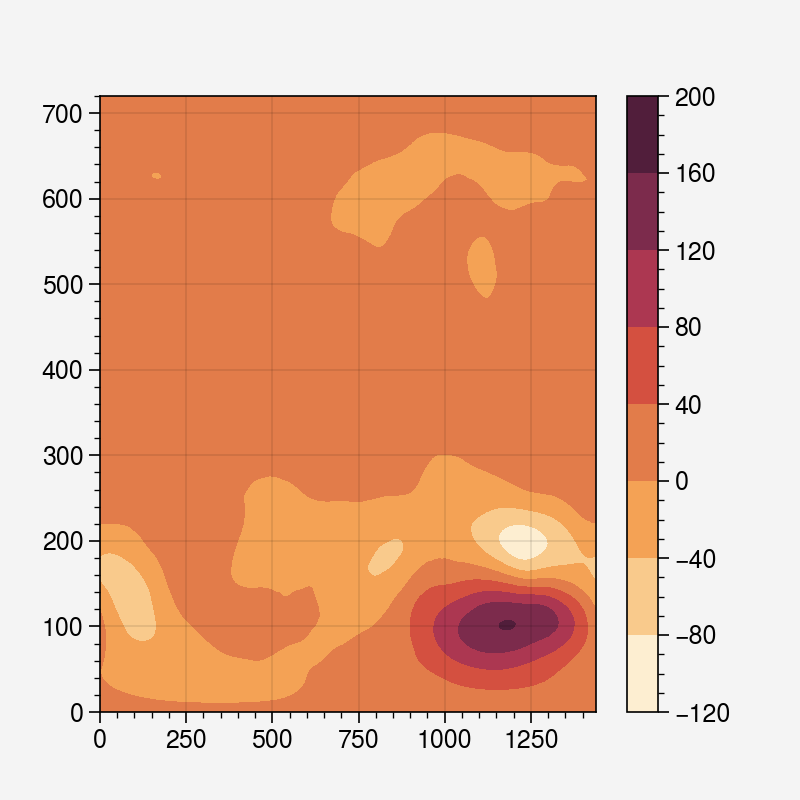

In [18]:
plt.contourf(cluster_comp['z'].sel(cluster=1))
plt.colorbar()

In [19]:
cluster4_freq=(ds_zanom.groupby('cluster').count())/len(ds_cluster['time'])
freq=np.round((cluster4_freq['z'][:,0,0].values)*100)

In [20]:
print("Days count in cluster")
ds_zanom['z'].groupby('cluster').count().values

Days count in cluster


array([[[1004, 1004, 1004, ..., 1004, 1004, 1004],
        [1004, 1004, 1004, ..., 1004, 1004, 1004],
        [1004, 1004, 1004, ..., 1004, 1004, 1004],
        ...,
        [1004, 1004, 1004, ..., 1004, 1004, 1004],
        [1004, 1004, 1004, ..., 1004, 1004, 1004],
        [1004, 1004, 1004, ..., 1004, 1004, 1004]],

       [[ 611,  611,  611, ...,  611,  611,  611],
        [ 611,  611,  611, ...,  611,  611,  611],
        [ 611,  611,  611, ...,  611,  611,  611],
        ...,
        [ 611,  611,  611, ...,  611,  611,  611],
        [ 611,  611,  611, ...,  611,  611,  611],
        [ 611,  611,  611, ...,  611,  611,  611]],

       [[ 995,  995,  995, ...,  995,  995,  995],
        [ 995,  995,  995, ...,  995,  995,  995],
        [ 995,  995,  995, ...,  995,  995,  995],
        ...,
        [ 995,  995,  995, ...,  995,  995,  995],
        [ 995,  995,  995, ...,  995,  995,  995],
        [ 995,  995,  995, ...,  995,  995,  995]],

       [[ 909,  909,  909, ...,  909,

In [21]:
da_freq=xr.DataArray(freq,
                    coords={'cluster': cluster_comp['cluster']},
                            dims=['cluster'])
#titles=['West Coast High','Pacific Trough','Alaskan Ridge/Pacific Ridge','Greenland High',]
titles=['Alaskan Ridge/Pacific Ridge','Greenland High','Pacific Trough','West Coast High',]

da_names=xr.DataArray(titles,coords={'cluster': cluster_comp['cluster']},
                      dims=['cluster'])


cluster_comp['freq']=da_freq
cluster_comp['names']=da_names

In [22]:
freq

array([29., 17., 28., 26.])

In [23]:
cluster_comp

<xarray.Dataset>
Dimensions:  (lon: 1440, lat: 721, cluster: 4)
Coordinates:
  * lon      (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0
  * cluster  (cluster) int64 0 1 2 3
Data variables:
    z        (cluster, lat, lon) float64 5.125 5.125 5.125 ... 4.141 4.141 4.141
    freq     (cluster) float64 29.0 17.0 28.0 26.0
    names    (cluster) <U27 'Alaskan Ridge/Pacific Ridge' ... 'West Coast High'

In [25]:
cluster_comp.to_netcdf('../data/wxregimes/era5_cluster_comp_z_na_'+seas+'1981-2019.nc')

In [ ]:
nrows=2
ncols=2
lon_0=260
f, axs = pplt.subplots(nrows=nrows,ncols=2,span=False,proj='npstere',proj_kw={'lon_0': lon_0},
                           figsize=(8.5,11.0),sharex=False,sharey=False)
axs.format(abc=True, abcloc='l', abcstyle='(a)')
levs=np.arange(-90,100,10)
cmap='NegPos'
titles=cluster_comp['names'].values
k=0
for i in np.arange(nrows):
    for j in np.arange(ncols):

        # Make a filled contour plot
        cs1=axs[i,j].contourf(cluster_comp['lon'].values,cluster_comp['lat'].values,cluster_comp['z'][k,:,:].values,
                        cmap=cmap,extend='both',levels=levs,suptitle='ERA5 Z500 Anomalies DJF 1981-2019',
                        labels_kw={'fontsize': 'large'})
        
        axs[i,j].format(title=titles[k]+' ('+str(freq[k])+'%)',
                  reso='lo', coastcolor='black',
                  coast=True, innerborders=False, grid=False, boundinglat=10)
        k=k+1
        
f.colorbar(cs1,loc='b',length=0.6,label="m")
f.savefig('../figs/era5_cluster_comp_z_na_'+seas+'1981-2019.png')

### CHIRPS Precip Data

In [ ]:
fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/chirps-v2.0/p05/*'
ds_precip=xr.open_mfdataset(fname_precip,combine='by_coords')
ds_precip = ds_precip.rename({'latitude':'lat','longitude':'lon'})
ds_precip=ds_precip.assign_coords(lon=((ds_precip['lon'] + 360) % 360))
ds_precip=ds_precip.sortby(ds_precip['lon'])
ds_precip

In [ ]:
ds_precip_NA=ds_precip.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [ ]:
ds_precip_NA

In [ ]:
# Make Anoms
ds_pclimo=ds_precip_NA.sel(time=slice(sdate,edate)).groupby('time.dayofyear').mean()
ds_panom=ds_precip_NA.groupby('time.dayofyear')-ds_pclimo

# Select the dates
ds_panom=ds_panom.sel(time=slice(sdate,edate))

ds_panom = ds_panom.sel(time=ds_panom['time.month'].isin(seas_mon))

In [ ]:
ds_panom['time']=ds_cluster['cluster']
ds_panom=ds_panom.rename({'time':'cluster'})
ds_panom

In [ ]:
cluster_pcomp=ds_panom.groupby('cluster').mean().compute()
cluster_pcomp

In [ ]:
cluster_pcomp.to_netcdf(data_path+'era5_cluster_comp_p_na_'+seas+'1981-2019.nc')

In [ ]:
nrows=2
ncols=2
lon_0=260
f, axs = pplt.subplots(nrows=nrows,ncols=2,span=False,proj='pcarree',proj_kw={'lon_0': lon_0},
                           figsize=(11.0,8.5),sharex=False,sharey=False)
axs.format(abc=True, abcloc='l', abcstyle='(a)')
levs=np.arange(-1,1.2,0.2)
cmap='DryWet'
k=0
for i in np.arange(nrows):
    for j in np.arange(ncols):

        # Make a filled contour plot
        cs1=axs[i,j].contourf(cluster_pcomp['lon'].values,cluster_pcomp['lat'].values,cluster_pcomp['precip'][k,:,:].values,
                        cmap=cmap,extend='both',levels=levs,
                        labels_kw={'fontsize': 'large'})
        
        axs[i,j].format(title=titles[k],
                  reso='lo', coastcolor='black',suptitle='CHIRPS Global Precip Anomalies DJF 1981-2019',
                  coast=True, innerborders=False, grid=False, lonlim=(225,300), latlim=(20,50))
        axs[i,j].add_feature(cfeature.STATES,edgecolor='gray') 

        k=k+1
        
f.colorbar(cs1,loc='b',length=0.6,label="mm/day") 
f.savefig('../figs/chirps05_cluster_comp_p_na_'+seas+'1981-2019.png')